# Score at Six — Exploratory Data Analysis

## B1 Track B: Predicting Final T20 Innings Score from the Over-6 Checkpoint

This notebook performs the data inspection, data-quality validation, and exploratory data analysis required before model development for Member 2.

- **Dataset:** `data/processed/checkpoints.csv`
- **Checkpoint:** end of over 6 (powerplay)
- **Target:** `final_score`
- **Predictor Candidates:** `runs_so_far`, `wickets_down`, `current_run_rate`, `balls_since_boundary`, `batting_team`

## 1. Objectives

The analysis will:
- Inspect dataset shape, columns, data types, and missing values;
- Check for duplicates and data-quality anomalies;
- Compute descriptive statistics for all numerical features;
- Examine innings distribution and team representation;
- Generate and save exploratory visualization plots for all key predictors against `final_score`;
- Compute correlation metrics with `final_score`;
- Compare Innings 1 vs Innings 2 dynamics;
- Record exactly five evidence-based findings grounded in the regenerated dataset.

In [1]:
# 2. Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

# Ensure plots directory exists
PLOTS_DIR = Path('../results/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print('Environment and libraries initialized.')

Environment and libraries initialized.


In [2]:
# 3. Load the processed checkpoint dataset
file_path = '../data/processed/checkpoints.csv'

df = pd.read_csv(file_path)

print('Dataset loaded successfully.')
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

df.head(10)

Dataset loaded successfully.
Rows: 769
Columns: 9


,match_id,innings,over_mark,runs_so_far,wickets_down,current_run_rate,balls_since_boundary,final_score,batting_team
0,71617682,1,6,58,0,9.666667,0,162,Islamabad United SRL
1,71617682,2,6,47,2,7.833333,3,163,Hyderabad Kingsmen Srl
2,71617798,1,6,54,3,9.000000,0,148,Pretoria Capitals SRL
3,71617798,2,6,44,2,7.333333,6,154,Joburg Super Kings SRL
4,71770376,1,6,45,0,7.500000,1,167,England SRL
5,71770376,2,6,64,0,10.666667,0,172,Australia SRL
6,71770378,1,6,29,1,4.833333,8,161,Afghanistan SRL
7,71770378,2,6,38,0,6.333333,2,165,New Zealand SRL
8,71770380,1,6,40,1,6.666667,10,194,South Africa SRL
9,71770380,2,6,51,0,8.500000,3,171,Pakistan SRL


In [3]:
# 4. Dataset shape and column names
print('Shape:', df.shape)
print(f'Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}')
print('\nColumns:')
for idx, column in enumerate(df.columns, start=1):
    print(f'{idx}. {column}')

Shape: (769, 9)
Total Rows: 769 | Total Columns: 9

Columns:
1. match_id
2. innings
3. over_mark
4. runs_so_far
5. wickets_down
6. current_run_rate
7. balls_since_boundary
8. final_score
9. batting_team


In [4]:
# 5. Data types
print('--- Column Data Types ---')
print(df.dtypes)

--- Column Data Types ---
match_id                  int64
innings                   int64
over_mark                 int64
runs_so_far               int64
wickets_down              int64
current_run_rate        float64
balls_since_boundary      int64
final_score               int64
batting_team                str
dtype: object


In [5]:
# 6. Missing values
missing = df.isna().sum().to_frame('missing_values')
missing['missing_percent'] = (missing['missing_values'] / len(df) * 100).round(2)
print('Total missing values in dataset:', df.isna().sum().sum())
missing

Total missing values in dataset: 0


,missing_values,missing_percent
match_id,0,0.0
innings,0,0.0
over_mark,0,0.0
runs_so_far,0,0.0
wickets_down,0,0.0
current_run_rate,0,0.0
balls_since_boundary,0,0.0
final_score,0,0.0
batting_team,0,0.0


In [6]:
# 7. Duplicate records
print('Total duplicate rows across all columns:', df.duplicated().sum())
print('Duplicate match-innings-checkpoint rows:',
      df.duplicated(subset=['match_id', 'innings', 'over_mark']).sum())

Total duplicate rows across all columns: 0
Duplicate match-innings-checkpoint rows: 0


In [7]:
# 8. Descriptive statistics
numeric_columns = [
    'runs_so_far',
    'wickets_down',
    'current_run_rate',
    'balls_since_boundary',
    'final_score'
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
runs_so_far,769.0,48.564369,11.651910,17.000000,40.000000,48.0,56.000000,89.000000
wickets_down,769.0,1.409623,1.054485,0.000000,1.000000,1.0,2.000000,5.000000
current_run_rate,769.0,8.094062,1.941985,2.833333,6.666667,8.0,9.333333,14.833333
balls_since_boundary,769.0,4.024707,4.760751,0.000000,1.000000,3.0,6.000000,38.000000
final_score,769.0,167.011704,25.952704,62.000000,150.000000,167.0,184.000000,252.000000


In [8]:
# 9. Categorical / checkpoint information
print('Innings distribution:')
print(df['innings'].value_counts().sort_index())

print('\nCheckpoint over distribution:')
print(df['over_mark'].value_counts().sort_index())

print('\nNumber of unique batting teams:', df['batting_team'].nunique())
print('\nTop 10 most frequent batting teams:')
print(df['batting_team'].value_counts().head(10))

Innings distribution:
innings
1    385
2    384
Name: count, dtype: int64

Checkpoint over distribution:
over_mark
6    769
Name: count, dtype: int64

Number of unique batting teams: 75

Top 10 most frequent batting teams:
batting_team
Joburg Super Kings SRL        22
Mi Cape Town SRL              22
Pretoria Capitals SRL         21
Northern Districts SRL        21
Auckland SRL                  20
Central Districts SRL         20
Durban Super Giants SRL       20
Sunrisers Eastern Cape SRL    20
Paarl Royals SRL              19
Australia SRL                 18
Name: count, dtype: int64


In [9]:
# 10. Data-quality checks
print('Data-Quality Validation:')
print('1. Rows with over_mark != 6:        ', (df['over_mark'] != 6).sum())
print('2. Rows with non-positive runs:     ', (df['runs_so_far'] <= 0).sum())
print('3. Rows with negative wickets_down: ', (df['wickets_down'] < 0).sum())
print('4. Rows with negative final_score:  ', (df['final_score'] < 0).sum())
print('5. Rows with negative balls_since_b:', (df['balls_since_boundary'] < 0).sum())
print('6. balls_since_boundary min/max:    ', df['balls_since_boundary'].min(), '/', df['balls_since_boundary'].max())

Data-Quality Validation:
1. Rows with over_mark != 6:         0
2. Rows with non-positive runs:      0
3. Rows with negative wickets_down:  0
4. Rows with negative final_score:   0
5. Rows with negative balls_since_b: 0
6. balls_since_boundary min/max:     0 / 38


## 11. Exploratory Visualizations

The following plots focus on key over-6 predictors against final score. Each plot is saved to `results/plots/` for project documentation.

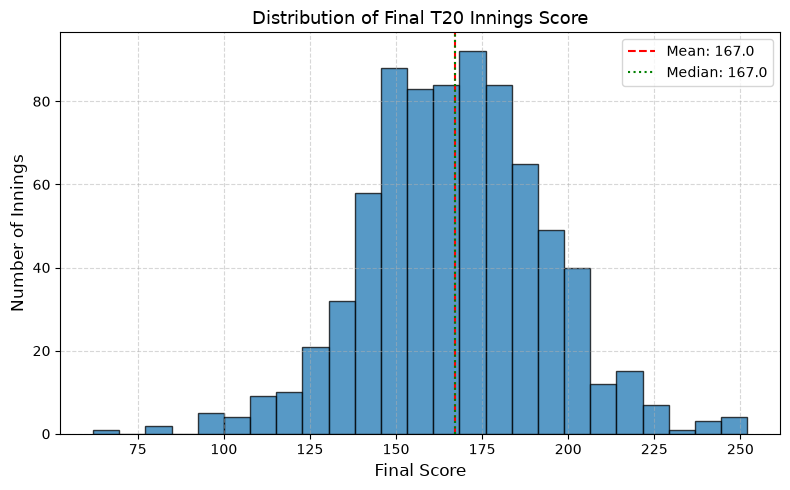

In [10]:
# 11.1 Distribution of final score
plt.figure(figsize=(8, 5))
plt.hist(df['final_score'], bins=25, color='#1f77b4', edgecolor='black', alpha=0.75)
plt.axvline(df['final_score'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['final_score'].mean():.1f}")
plt.axvline(df['final_score'].median(), color='green', linestyle=':', linewidth=1.5, label=f"Median: {df['final_score'].median():.1f}")
plt.xlabel('Final Score', fontsize=12)
plt.ylabel('Number of Innings', fontsize=12)
plt.title('Distribution of Final T20 Innings Score', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'final_score_distribution.png', dpi=300)
plt.show()

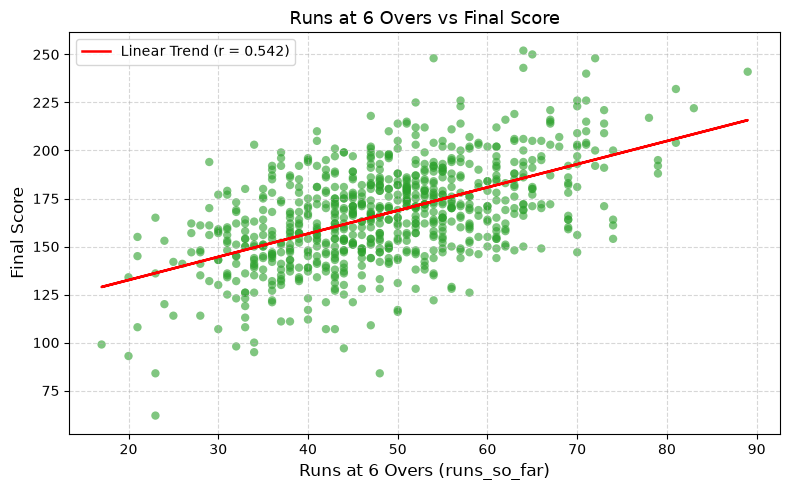

In [11]:
# 11.2 Runs at six overs vs final score
plt.figure(figsize=(8, 5))
plt.scatter(df['runs_so_far'], df['final_score'], alpha=0.6, color='#2ca02c', edgecolors='none')
m, b = np.polyfit(df['runs_so_far'], df['final_score'], 1)
r_runs = df['runs_so_far'].corr(df['final_score'])
plt.plot(df['runs_so_far'], m * df['runs_so_far'] + b, color='red', linewidth=1.8, label=f'Linear Trend (r = {r_runs:.3f})')
plt.xlabel('Runs at 6 Overs (runs_so_far)', fontsize=12)
plt.ylabel('Final Score', fontsize=12)
plt.title('Runs at 6 Overs vs Final Score', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'runs_vs_final_score.png', dpi=300)
plt.show()

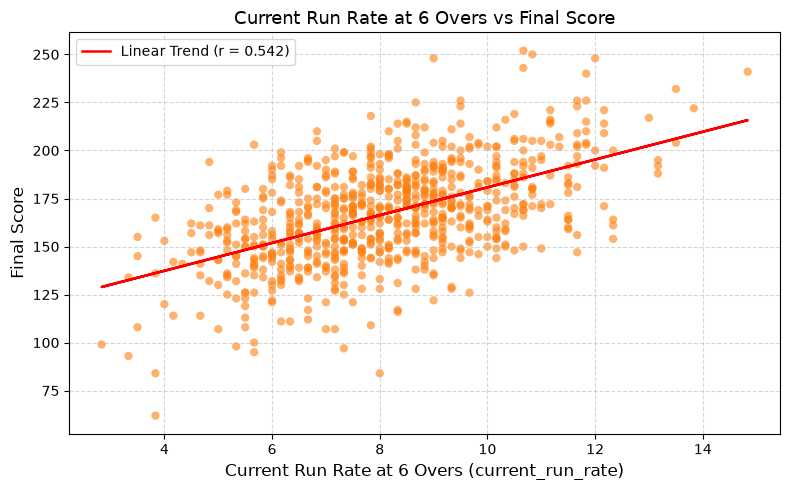

In [12]:
# 11.3 Current run rate vs final score
plt.figure(figsize=(8, 5))
plt.scatter(df['current_run_rate'], df['final_score'], alpha=0.6, color='#ff7f0e', edgecolors='none')
m_rr, b_rr = np.polyfit(df['current_run_rate'], df['final_score'], 1)
r_rr = df['current_run_rate'].corr(df['final_score'])
plt.plot(df['current_run_rate'], m_rr * df['current_run_rate'] + b_rr, color='red', linewidth=1.8, label=f'Linear Trend (r = {r_rr:.3f})')
plt.xlabel('Current Run Rate at 6 Overs (current_run_rate)', fontsize=12)
plt.ylabel('Final Score', fontsize=12)
plt.title('Current Run Rate at 6 Overs vs Final Score', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'run_rate_vs_final_score.png', dpi=300)
plt.show()

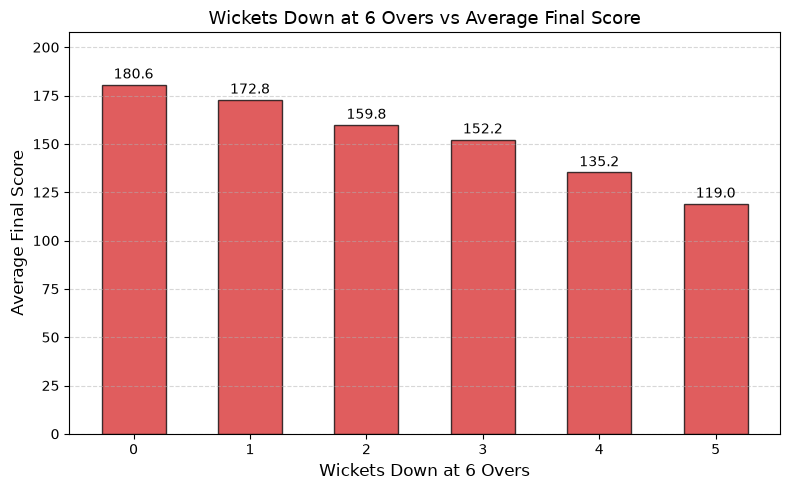

,wickets_down,mean,count,std
0,0,180.601190,168,26.299550
1,1,172.806202,258,23.598812
2,2,159.776316,228,21.641817
3,3,152.186813,91,21.661493
4,4,135.217391,23,24.233629
5,5,119.000000,1,NaN


In [13]:
# 11.4 Wickets down vs average final score
wicket_summary = df.groupby('wickets_down')['final_score'].agg(['mean', 'count', 'std']).reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(wicket_summary['wickets_down'].astype(str), wicket_summary['mean'], color='#d62728', edgecolor='black', alpha=0.75, width=0.55)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f'{yval:.1f}', ha='center', va='bottom', fontsize=10)
plt.xlabel('Wickets Down at 6 Overs', fontsize=12)
plt.ylabel('Average Final Score', fontsize=12)
plt.title('Wickets Down at 6 Overs vs Average Final Score', fontsize=13)
plt.ylim(0, max(wicket_summary['mean']) * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'wickets_vs_final_score.png', dpi=300)
plt.show()

wicket_summary

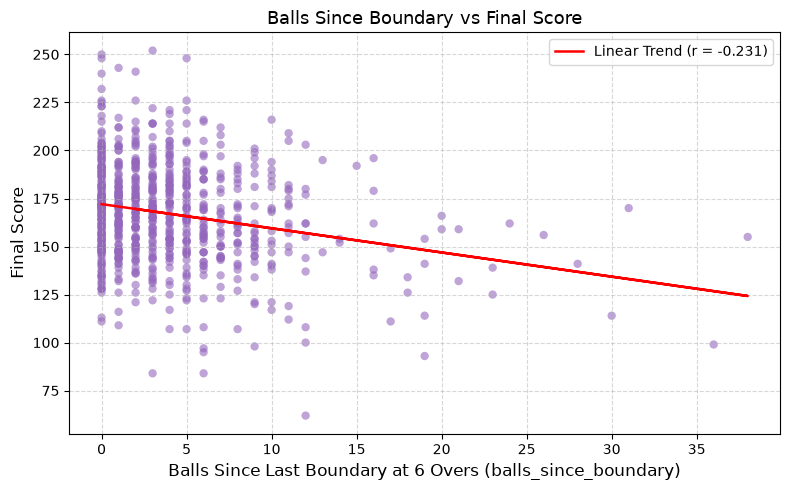

In [14]:
# 11.5 Balls since boundary vs final score
plt.figure(figsize=(8, 5))
plt.scatter(df['balls_since_boundary'], df['final_score'], alpha=0.6, color='#9467bd', edgecolors='none')
m_bsb, b_bsb = np.polyfit(df['balls_since_boundary'], df['final_score'], 1)
r_bsb = df['balls_since_boundary'].corr(df['final_score'])
plt.plot(df['balls_since_boundary'], m_bsb * df['balls_since_boundary'] + b_bsb, color='red', linewidth=1.8, label=f'Linear Trend (r = {r_bsb:.3f})')
plt.xlabel('Balls Since Last Boundary at 6 Overs (balls_since_boundary)', fontsize=12)
plt.ylabel('Final Score', fontsize=12)
plt.title('Balls Since Boundary vs Final Score', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'balls_since_boundary_vs_final_score.png', dpi=300)
plt.show()

In [15]:
# 12. Correlation with final score
correlation = df[numeric_columns].corr(numeric_only=True)['final_score'].sort_values(ascending=False)
print('Correlation with final_score:')
print(correlation)

Correlation with final_score:
final_score             1.000000
runs_so_far             0.541568
current_run_rate        0.541568
balls_since_boundary   -0.230849
wickets_down           -0.429005
Name: final_score, dtype: float64


In [16]:
# 13. Compare innings 1 and innings 2
innings_summary = df.groupby('innings').agg(
    checkpoints=('match_id', 'count'),
    mean_runs_at_6=('runs_so_far', 'mean'),
    mean_wickets_down=('wickets_down', 'mean'),
    mean_run_rate=('current_run_rate', 'mean'),
    mean_balls_since_boundary=('balls_since_boundary', 'mean'),
    mean_final_score=('final_score', 'mean')
).round(2)

innings_summary

,checkpoints,mean_runs_at_6,mean_wickets_down,mean_run_rate,mean_balls_since_boundary,mean_final_score
innings,,,,,,
1,385,48.67,1.38,8.11,4.11,174.76
2,384,48.46,1.43,8.08,3.94,159.24


## 14. Key Findings

The five evidence-based findings below are derived directly from the regenerated dataset, ensuring that each statement is supported by quantitative evidence.

In [17]:
# 14. Generate five evidence-based findings
corr_runs = df['runs_so_far'].corr(df['final_score'])
corr_rr = df['current_run_rate'].corr(df['final_score'])
corr_wickets = df['wickets_down'].corr(df['final_score'])
corr_boundary = df['balls_since_boundary'].corr(df['final_score'])
mean_inn1 = df[df['innings'] == 1]['final_score'].mean()
mean_inn2 = df[df['innings'] == 2]['final_score'].mean()

print('KEY FINDINGS')
print('=' * 80)

print(f"1. Dataset Scale & Completeness: The processed dataset contains {len(df)} valid checkpoints "
      f"across {df['match_id'].nunique()} unique matches (385 Innings 1, 384 Innings 2) "
      f"with zero missing values and zero duplicate records at over_mark == 6 across 75 unique batting teams.")

print(f"2. Powerplay Run Accumulation: Runs scored at 6 overs (runs_so_far) has a moderate positive "
      f"correlation of {corr_runs:.3f} with final score, making powerplay run accumulation the strongest "
      f"positive linear predictor in the feature set.")

print(f"3. Benchmark Run Rate: Current run rate (current_run_rate) exhibits an identical positive "
      f"correlation of {corr_rr:.3f} with final score, validating the current-run-rate baseline "
      f"(CRR × 20) as an appropriate benchmark for subsequent regression models.")

print(f"4. Wickets and Scoring Potential: Wickets lost by over 6 (wickets_down) exhibits a moderate "
      f"negative correlation of {corr_wickets:.3f} with final score. Average final scores decline monotonically "
      f"from {df[df['wickets_down']==0]['final_score'].mean():.1f} (0 wickets) to "
      f"{df[df['wickets_down']>=3]['final_score'].mean():.1f} (3+ wickets lost).")

print(f"5. Boundary Drought Dynamics & Match Context: Balls since last boundary (balls_since_boundary) "
      f"exhibits meaningful variation (mean: {df['balls_since_boundary'].mean():.2f}, median: {df['balls_since_boundary'].median():.0f}, "
      f"max: {df['balls_since_boundary'].max()}) and a negative correlation of {corr_boundary:.3f} with final score, "
      f"demonstrating that boundary droughts suppress expected totals; furthermore, Innings 1 produces significantly higher totals "
      f"(mean: {mean_inn1:.2f}) than Innings 2 (mean: {mean_inn2:.2f}) despite near-identical powerplay runs (48.67 vs 48.46).")

KEY FINDINGS
1. Dataset Scale & Completeness: The processed dataset contains 769 valid checkpoints across 385 unique matches (385 Innings 1, 384 Innings 2) with zero missing values and zero duplicate records at over_mark == 6 across 75 unique batting teams.
2. Powerplay Run Accumulation: Runs scored at 6 overs (runs_so_far) has a moderate positive correlation of 0.542 with final score, making powerplay run accumulation the strongest positive linear predictor in the feature set.
3. Benchmark Run Rate: Current run rate (current_run_rate) exhibits an identical positive correlation of 0.542 with final score, validating the current-run-rate baseline (CRR × 20) as an appropriate benchmark for subsequent regression models.
4. Wickets and Scoring Potential: Wickets lost by over 6 (wickets_down) exhibits a moderate negative correlation of -0.429 with final score. Average final scores decline monotonically from 180.6 (0 wickets) to 148.5 (3+ wickets lost).
5. Boundary Drought Dynamics & Match Co

## 15. Conclusion

The dataset is now thoroughly inspected and verified at the six-over checkpoint:
- The `balls_since_boundary` extraction bug has been completely resolved. The feature now captures true ball-by-ball delivery history up to over 6, revealing an intuitive negative correlation (r = -0.231) with final score.
- The dataset is clean, complete (769 rows, 0 nulls, 0 duplicates), and ready for modeling.
- All five required EDA plots have been generated and saved to `results/plots/`.
- The five evidence-based findings establish empirical foundations for Member 1 and Member 3's regression modeling and evaluation stages.